In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('data/StudentsPerformance.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
col=[col for col in df.columns if df[col].nunique()<10]


In [12]:
for column in col:
    print(f'Categories for {column}:\n{df[column].unique()}\n')

Categories for gender:
['female' 'male']

Categories for race/ethnicity:
['group B' 'group C' 'group A' 'group D' 'group E']

Categories for parental level of education:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

Categories for lunch:
['standard' 'free/reduced']

Categories for test preparation course:
['none' 'completed']



In [13]:
num_col=[col for col in df.columns if df[col].dtype!='O']
cat_col=[col for col in df.columns if df[col].dtype=='O']
print('We have {} Numerical columns:{}'.format(len(num_col),num_col))
print('We have {} Categorical columns:{}'.format(len(cat_col),cat_col))

We have 3 Numerical columns:['math score', 'reading score', 'writing score']
We have 5 Categorical columns:['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [14]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average']=df['total_score']/3


Text(0.5, 0, 'Total Score')

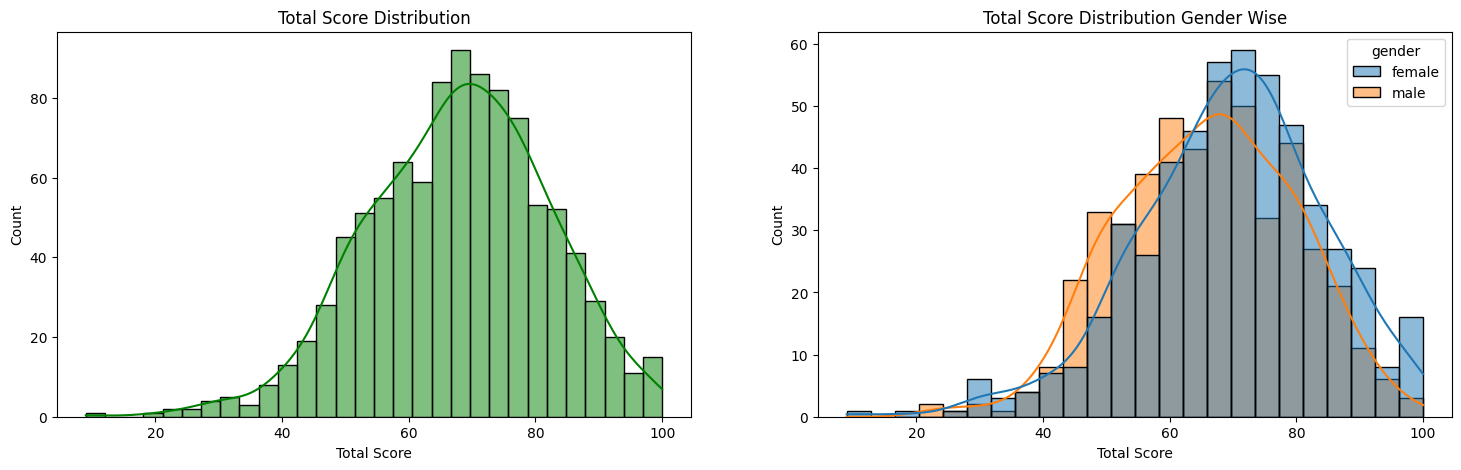

In [15]:
fig,axs=plt.subplots(1,2,figsize=(18,5))
plt.subplot(1,2,1)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
axs[0].set_title('Total Score Distribution')
axs[0].set_xlabel('Total Score')
plt.subplot(1,2,2)
sns.histplot(data=df,x='average',kde=True,hue='gender')
axs[1].set_title('Total Score Distribution Gender Wise')
axs[1].set_xlabel('Total Score')



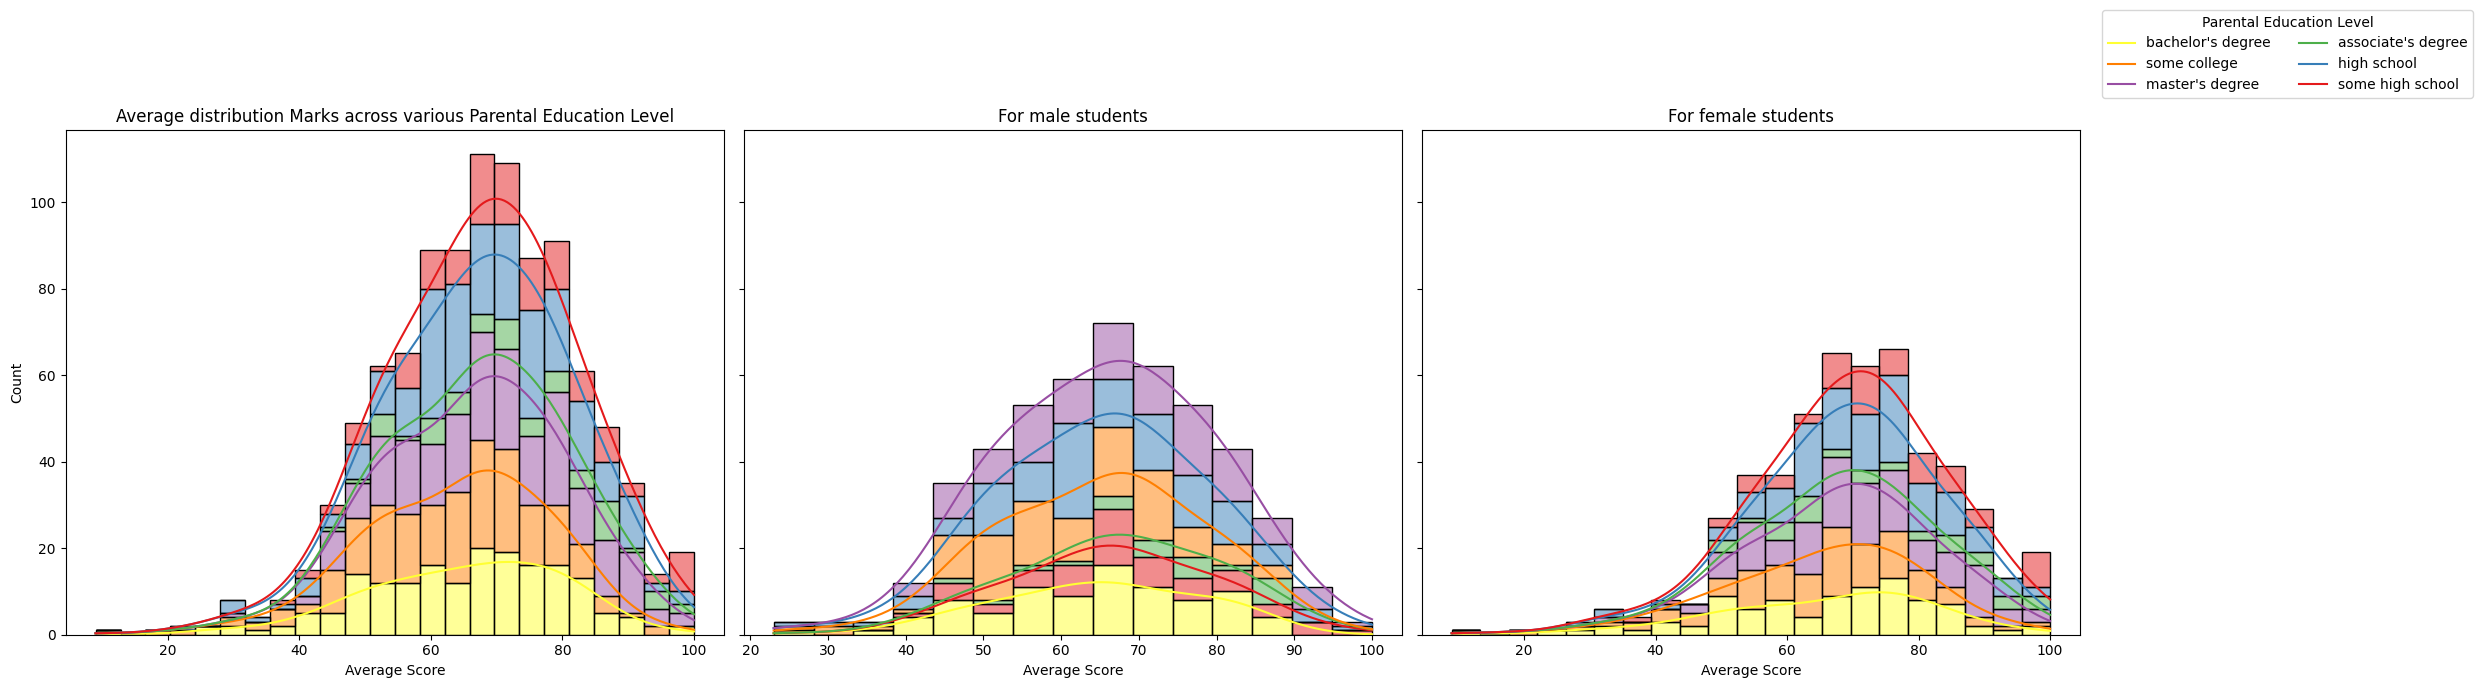

In [16]:
education_level = df['parental level of education'].unique()
color = sns.color_palette('Set1',len(education_level)) 
hue_colors = {}

for i, level in enumerate(education_level): 
    hue_colors[level] = color[i]

fig,axs = plt.subplots(1,3,sharey=True,figsize=(21,6))

sns.histplot(data=df,x='average',kde=True,hue='parental level of education',ax = axs[0],palette=hue_colors,legend=False,multiple="stack")
axs[0].set_title('Average distribution Marks across various Parental Education Level')
axs[0].set_xlabel('Average Score')

sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental level of education',ax = axs[1],palette=hue_colors,legend=False,multiple="stack")
axs[1].set_title('For male students')
axs[1].set_xlabel('Average Score')

sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental level of education',ax = axs[2],palette=hue_colors,legend=False,multiple="stack")
axs[2].set_title('For female students')
axs[2].set_xlabel('Average Score')

fig.legend(loc='upper left', bbox_to_anchor=(1,1.15), ncol=2,labels = hue_colors.keys(),title='Parental Education Level')
fig.tight_layout()
plt.show()

### Insight: Parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam(From 2nd plot)

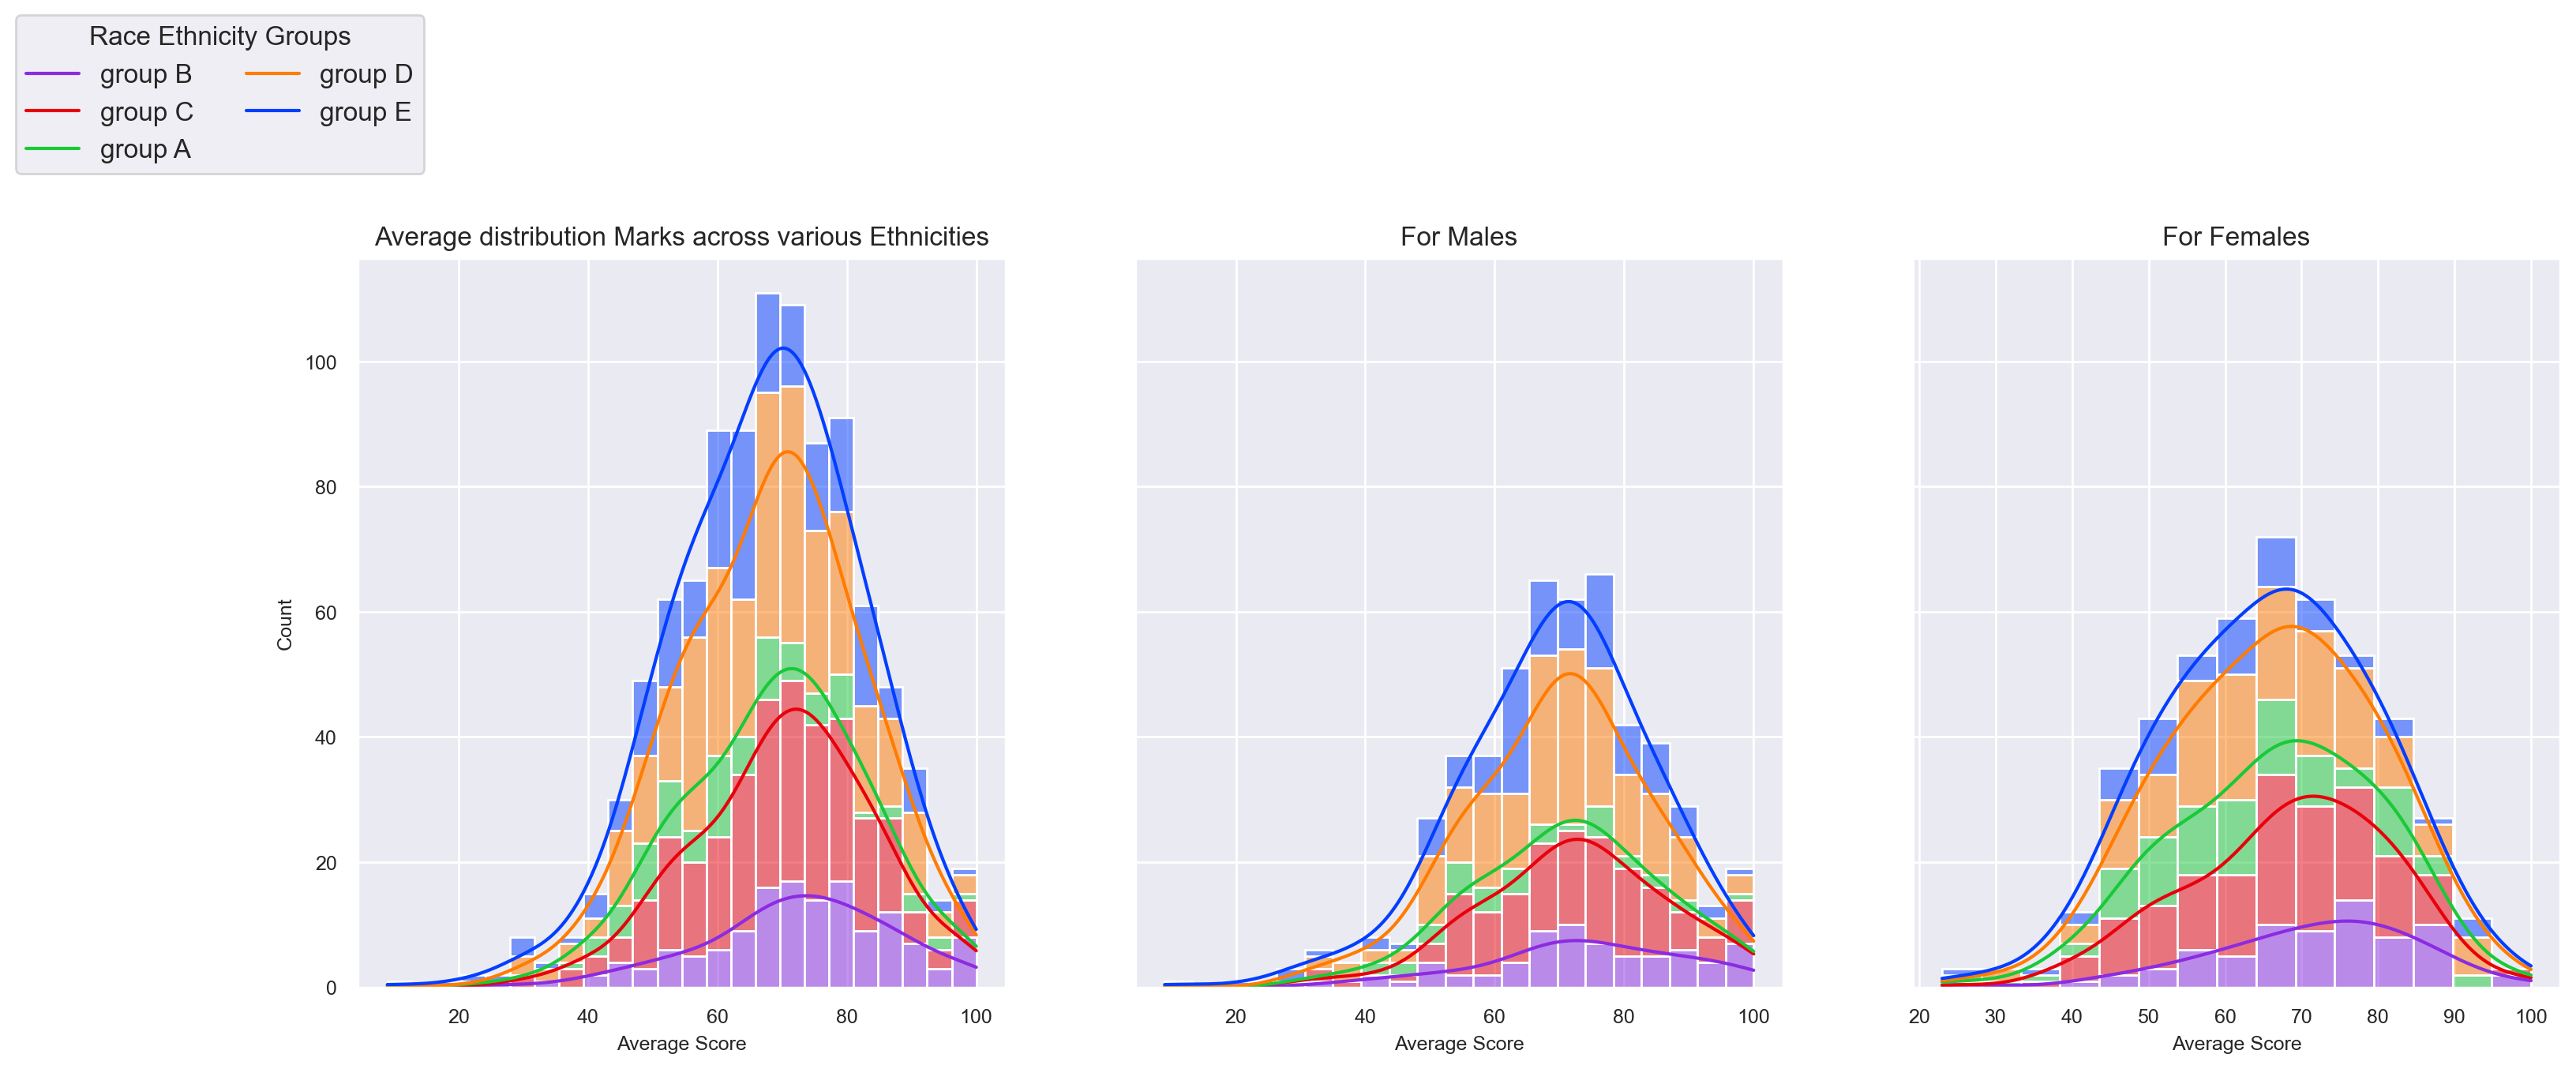

In [17]:
rcparams = {'figure.figsize':(18,9), 'axes.titlesize':12, 'axes.labelsize':9, 'xtick.labelsize':9, 'ytick.labelsize':9, 'legend.fontsize':12,'figure.dpi': 200}
sns.set(rc=rcparams)

fig,axs = plt.subplots(1,3,figsize=(18,6),sharey=True)
legend_labels = df['race/ethnicity'].unique()
sns.set_palette('bright')

sns.histplot(data=df,x='average',kde=True,hue='race/ethnicity',ax=axs[0],legend = False,multiple="stack")
axs[0].set_title('Average distribution Marks across various Ethnicities')
axs[0].set_xlabel('Average Score')

sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity',ax=axs[1],legend = False,multiple="stack")
axs[1].set_title('For Males')
axs[1].set_xlabel('Average Score')

sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity',ax=axs[2],legend=False,multiple="stack")
axs[2].set_title('For Females')
axs[2].set_xlabel('Average Score')
fig.legend(loc='upper left', bbox_to_anchor=(0,1.15), ncol=2,labels = legend_labels,title='Race Ethnicity Groups')
plt.show()

### Insight: Students of group A tends to perform poorly in exam.


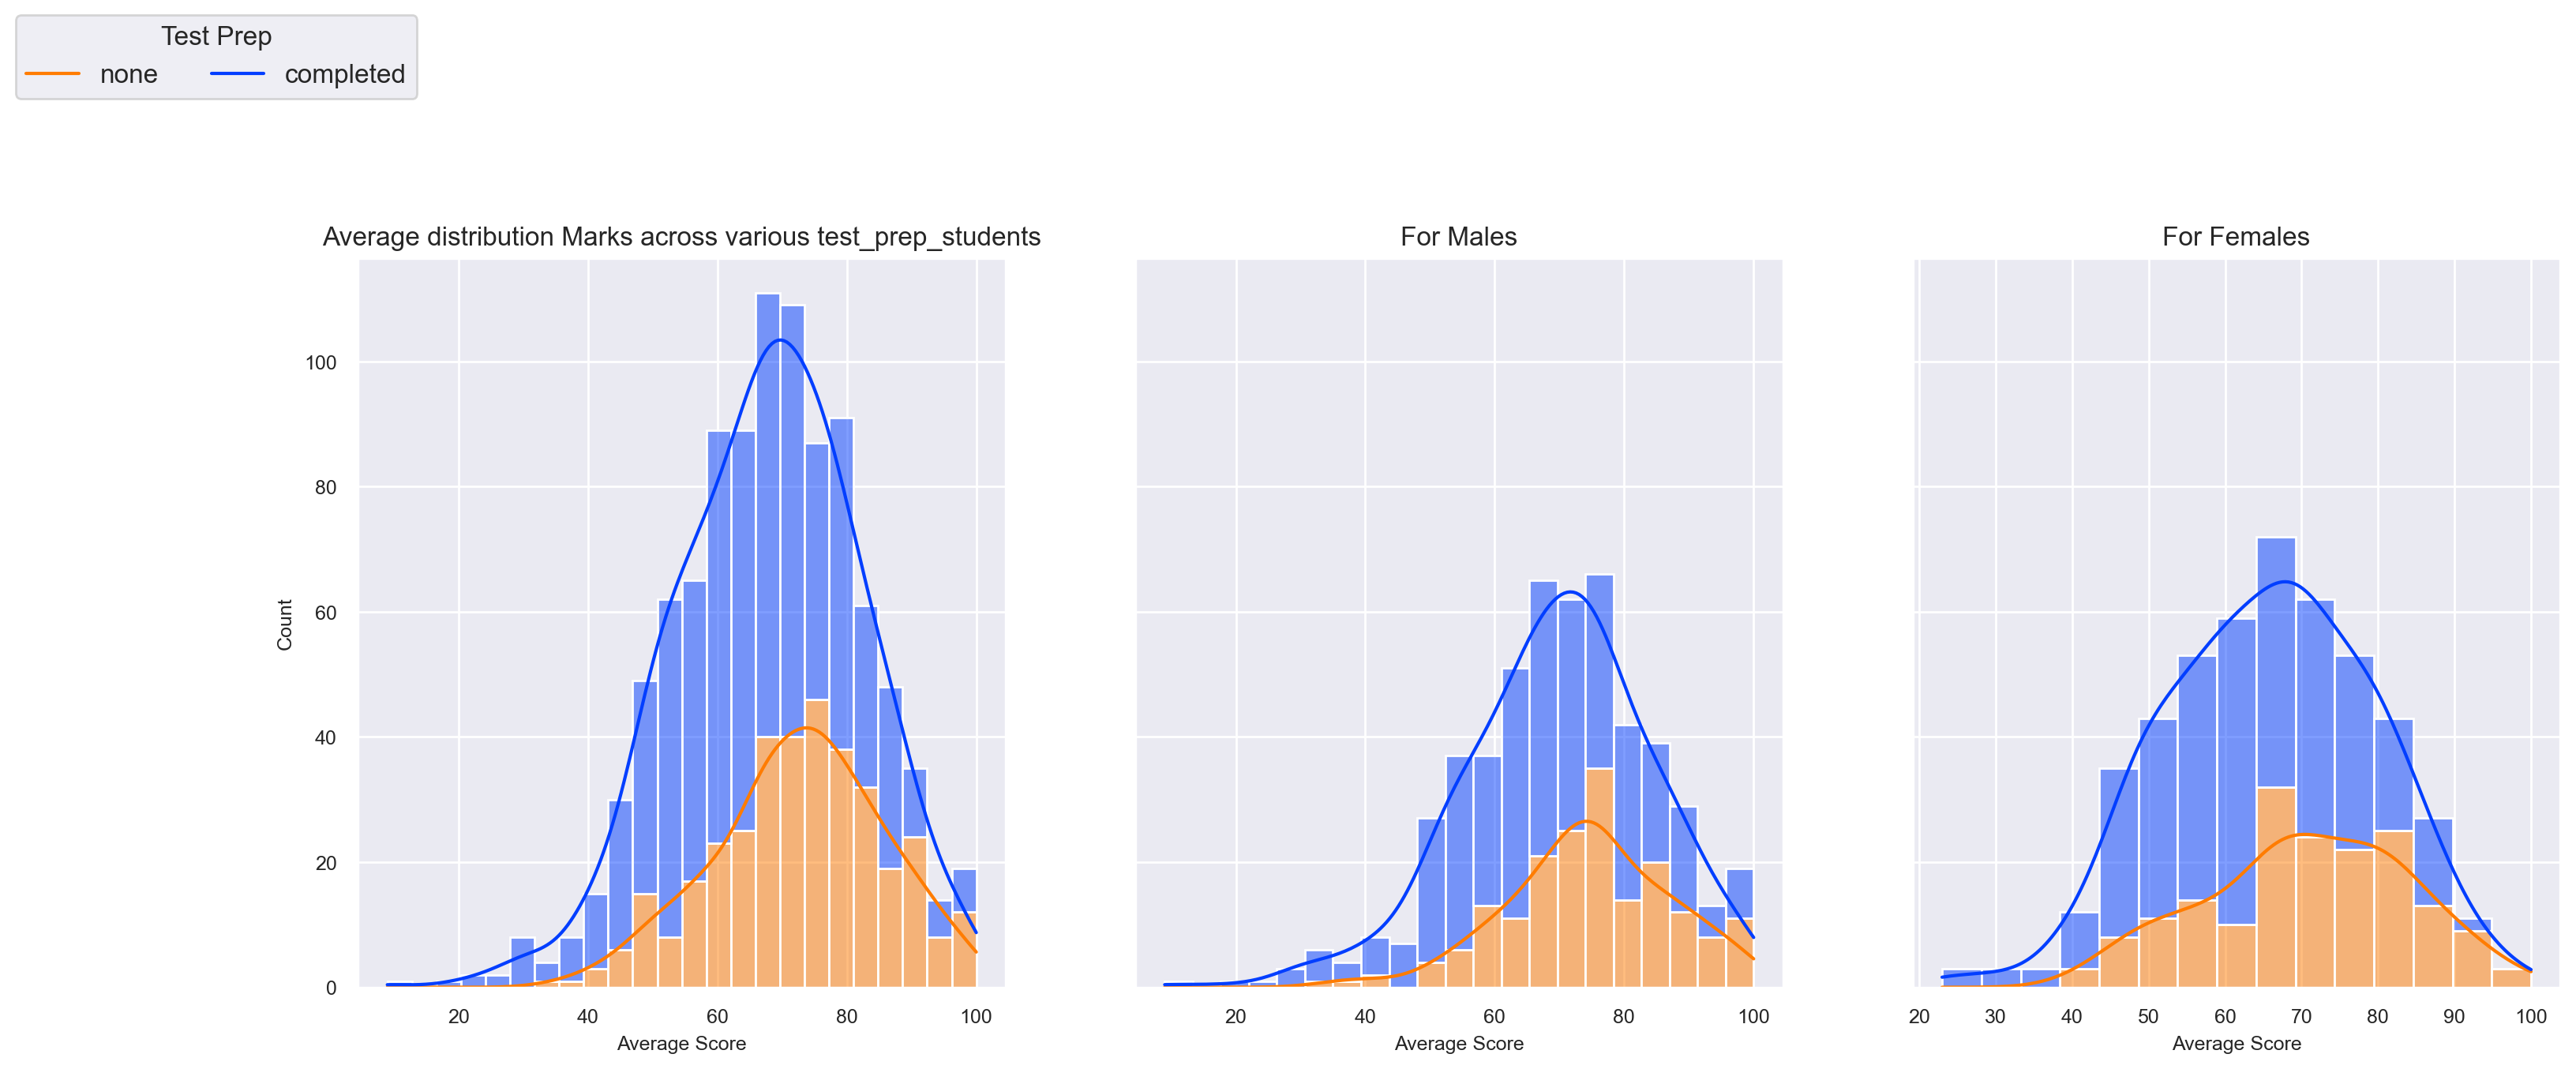

In [18]:

rcparams = {'figure.figsize':(18,9), 'axes.titlesize':12, 'axes.labelsize':9, 'xtick.labelsize':9, 'ytick.labelsize':9, 'legend.fontsize':12,'figure.dpi': 200}
sns.set(rc=rcparams)

fig,axs = plt.subplots(1,3,figsize=(18,6),sharey=True)
legend_labels = df['test preparation course'].unique()
sns.set_palette('bright')

sns.histplot(data=df,x='average',kde=True,hue='test preparation course',ax=axs[0],legend = False,multiple="stack")
axs[0].set_title('Average distribution Marks across various test_prep_students')
axs[0].set_xlabel('Average Score')

sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='test preparation course',ax=axs[1],legend = False,multiple="stack")
axs[1].set_title('For Males')
axs[1].set_xlabel('Average Score')

sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='test preparation course',ax=axs[2],legend=False,multiple="stack")
axs[2].set_title('For Females')
axs[2].set_xlabel('Average Score')
#handles, labels = axs[0].get_legend_handles_labels()
fig.legend(loc='upper left', bbox_to_anchor=(0,1.15), ncol=2,labels = legend_labels,title='Test Prep')
plt.show()

### Insight: Students who took test preparation generally achieved higher average scores, mostly ranging from 65 to 95, while those who did not take test preparation tended to score lower, primarily between 50 and 80

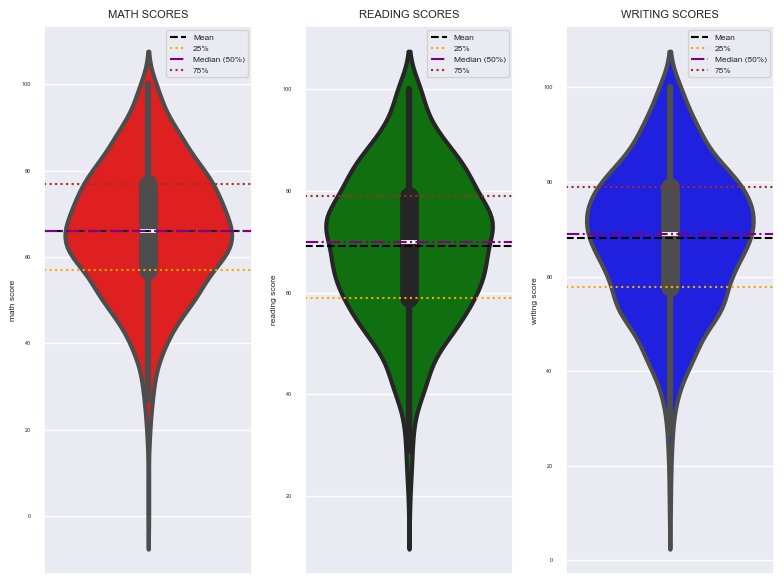

In [19]:
rcparams = {
    'figure.figsize': (8, 6),
    'axes.titlesize': 8,
    'axes.labelsize': 6,
    'xtick.labelsize': 4,
    'ytick.labelsize': 4,
    'legend.fontsize': 6,
    'figure.dpi': 100
}
sns.set(rc=rcparams)

fig, axs = plt.subplots(1, 3)

scores = [
    ('math score', 'red', 'MATH SCORES'),
    ('reading score', 'green', 'READING SCORES'),
    ('writing score', 'blue', 'WRITING SCORES')
]

for ax, (col, color, title) in zip(axs, scores):
    
    sns.violinplot(y=col, data=df, color=color, linewidth=3, ax=ax)
    ax.set_title(title)

    # Calculate statistics
    mean = df[col].mean()
    q25 = df[col].quantile(0.25)
    q50 = df[col].quantile(0.50)
    q75 = df[col].quantile(0.75)

    # Plot horizontal lines
    ax.axhline(mean, color='black', linestyle='--', label='Mean')
    ax.axhline(q25, color='orange', linestyle=':', label='25%')
    ax.axhline(q50, color='purple', linestyle='-.', label='Median (50%)')
    ax.axhline(q75, color='brown', linestyle=':', label='75%')

    ax.legend()

plt.tight_layout()
plt.show()


## Univariate Analysis


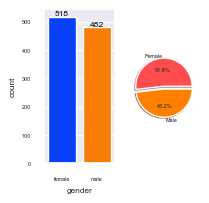

In [20]:

f,ax=plt.subplots(1,2,figsize=(2,2))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=6)
    
plt.pie(x=df['gender'].value_counts(),explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'],labels = ['Female','Male'],textprops={'fontsize': 4}
)
plt.show()

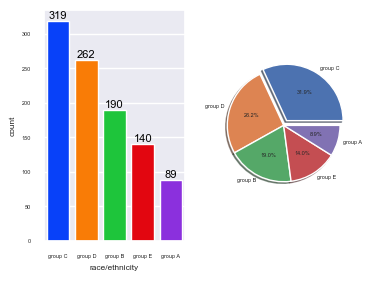

In [21]:
f,ax=plt.subplots(1,2,figsize=(4,3))
sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95,order=(df['race/ethnicity'].value_counts().index))
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=8)
    
plt.pie(x = (df['race/ethnicity'].value_counts()),labels=(df['race/ethnicity'].value_counts()).index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True,textprops={'fontsize': 4})
plt.show() 

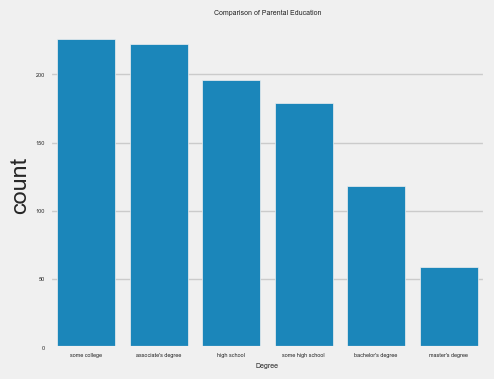

In [22]:

plt.rcParams['figure.figsize'] = (5, 4)
plt.style.use('fivethirtyeight')
sns.countplot(x = df['parental level of education'], order = df['parental level of education'].value_counts().index,)
plt.title('Comparison of Parental Education', fontweight = 7, fontsize = 5)
plt.xlabel('Degree', fontsize = 5)
plt.ylabel('count')
plt.show()

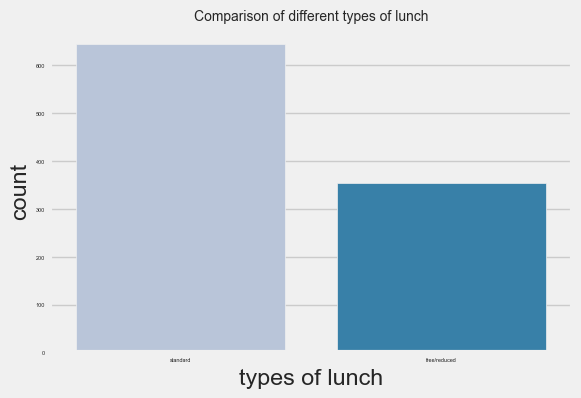

In [23]:
plt.rcParams['figure.figsize'] = (6, 4)
plt.style.use('fivethirtyeight')
sns.countplot(x = df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 15, fontsize = 10)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

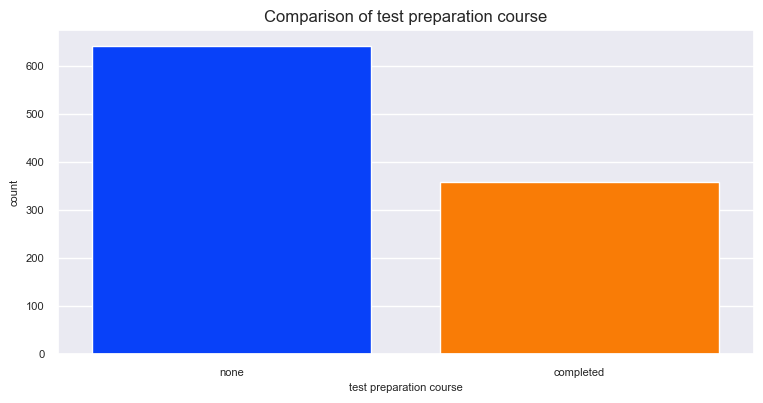

In [24]:
rcparams = {'figure.figsize':(8,4), 'axes.titlesize':12, 'axes.labelsize':8, 'xtick.labelsize':8, 'ytick.labelsize':8, 'legend.fontsize':8,'figure.dpi': 100}
sns.set(rc=rcparams) 

sns.countplot(x=df['test preparation course'],data=df,palette = 'bright',saturation=0.95,order=(df['test preparation course'].value_counts().index))
plt.title('Comparison of test preparation course')
plt.show()

## Bivariant Analysis

In [25]:
gender_group=df.groupby("gender").mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


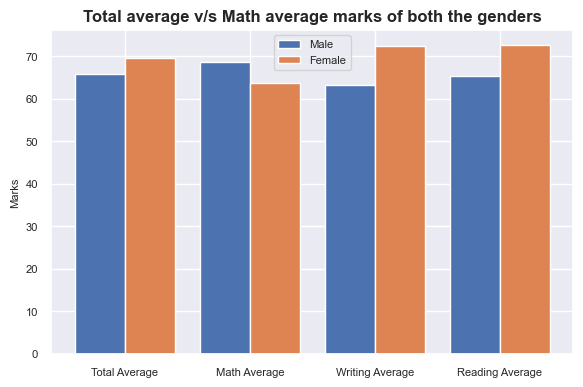

In [26]:
plt.figure(figsize=(6, 4))

X = ['Total Average','Math Average','Writing Average','Reading Average']


female_scores = [gender_group['average'][0], gender_group['math score'][0], gender_group['writing score'][0],gender_group['reading score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1],gender_group['writing score'][1],gender_group['reading score'][1]]

X_axis = np.arange(len(X)) # Giving a common axes for both the bars
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

### Insight: On an average females have a better overall score than men whereas males have scored higher in Maths

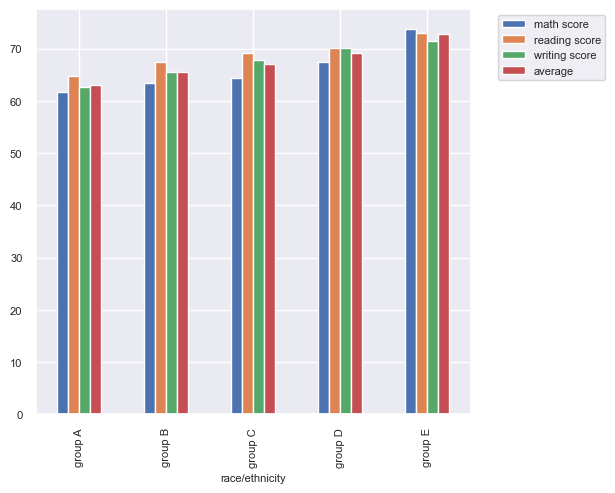

In [27]:
df.drop(columns=['total_score']).groupby('race/ethnicity').mean(numeric_only=True).plot(
    kind='bar',
    figsize=(5, 5)
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


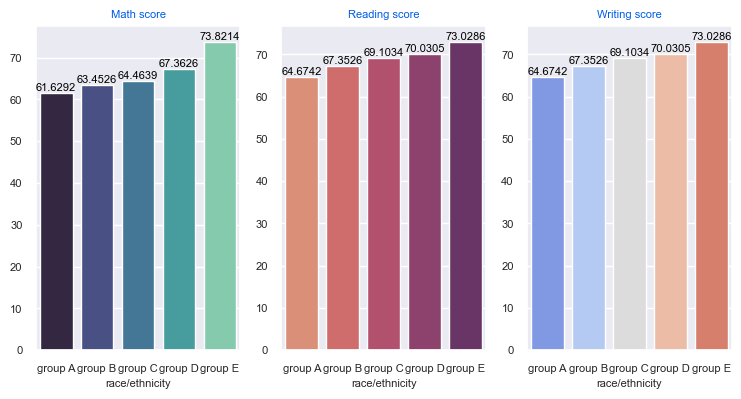

In [28]:

Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(8,4))    
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=8)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=8)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=8)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=8)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=8)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=8)

### Insight: Group E students have scored the highest average marks.Group A students have scored the lowest average marks.

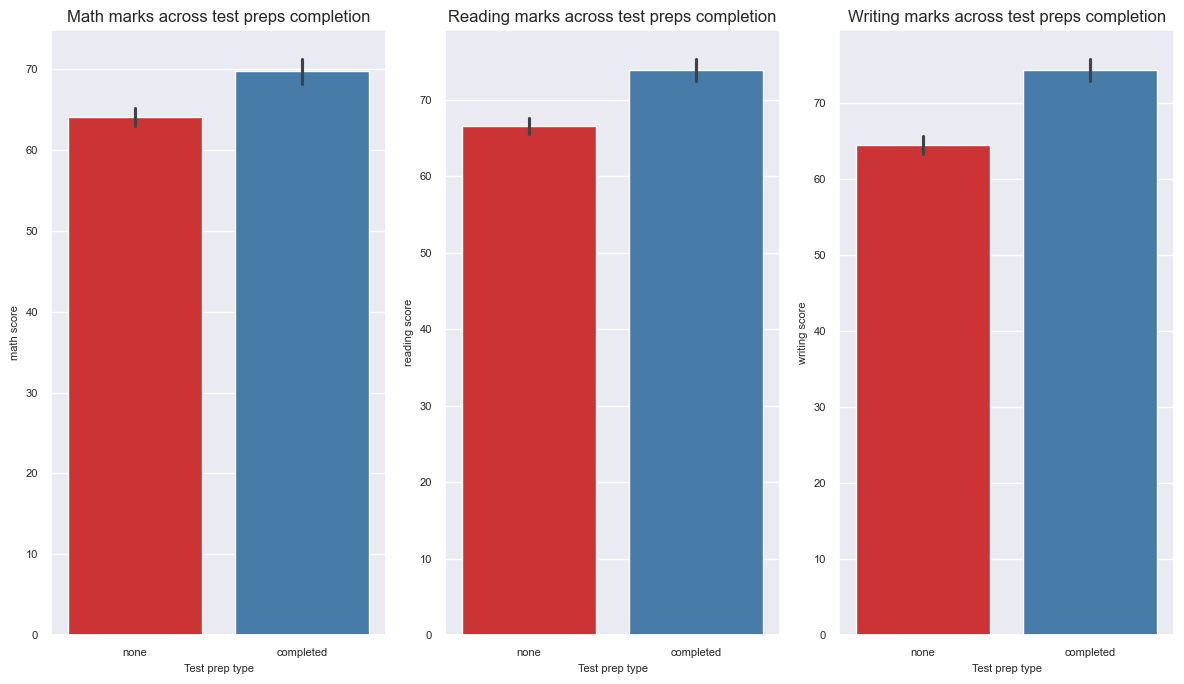

In [29]:

test_prep = df['test preparation course'].unique()
color = sns.color_palette('Set1',len(test_prep)) 
hue_colors = {}

for i, prep in enumerate(test_prep):
    hue_colors[prep] = color[i]
    
fig, axs = plt.subplots(1,3,sharex=True,figsize =(12,7))
sns.barplot(y=df['math score'], x = df['test preparation course'],ax = axs [0],palette=hue_colors)
axs[0].set_title('Math marks across test preps completion')
axs[0].set_xlabel('Test prep type')

sns.barplot(y=df['reading score'], x = df['test preparation course'],ax = axs [1],palette=hue_colors)
axs[1].set_title('Reading marks across test preps completion')
axs[1].set_xlabel('Test prep type')

sns.barplot(y=df['writing score'], x = df['test preparation course'],ax = axs [2],palette=hue_colors)
axs[2].set_title('Writing marks across test preps completion')
axs[2].set_xlabel('Test prep type')

fig.tight_layout()
plt.show()

### Insight: Students who have completed the test prep course completion have higher scores across all exams

## Outliers

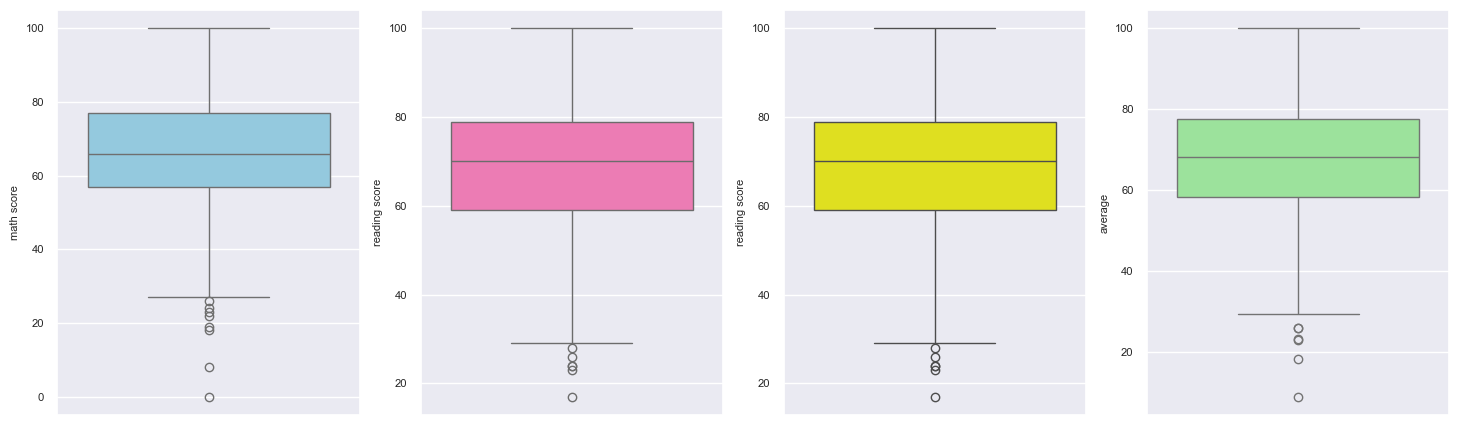

In [30]:

plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['reading score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

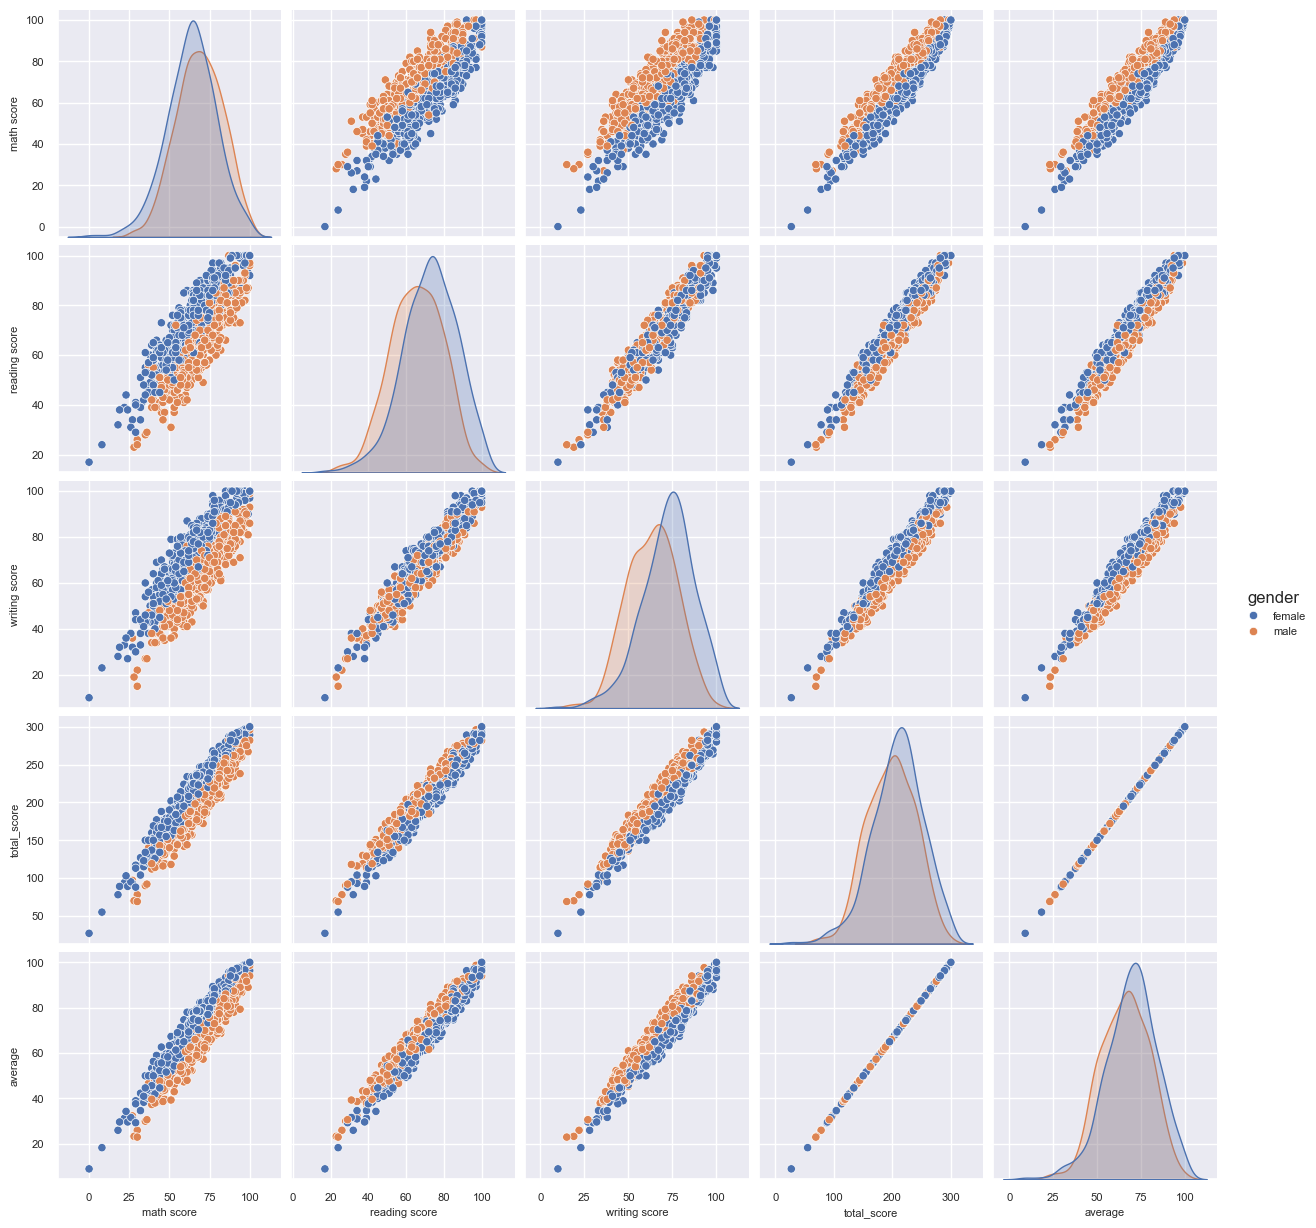

In [31]:
sns.pairplot(df,hue = 'gender')
plt.show()

Unique Education Levels: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Color Palette: [(0.8941176470588236, 0.10196078431372549, 0.10980392156862745), (0.21568627450980393, 0.49411764705882355, 0.7215686274509804), (0.30196078431372547, 0.6862745098039216, 0.2901960784313726), (0.596078431372549, 0.3058823529411765, 0.6392156862745098), (1.0, 0.4980392156862745, 0.0), (1.0, 1.0, 0.2)]
Mapping bachelor's degree to color (0.8941176470588236, 0.10196078431372549, 0.10980392156862745)
Mapping some college to color (0.21568627450980393, 0.49411764705882355, 0.7215686274509804)
Mapping master's degree to color (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)
Mapping associate's degree to color (0.596078431372549, 0.3058823529411765, 0.6392156862745098)
Mapping high school to color (1.0, 0.4980392156862745, 0.0)
Mapping some high school to color (1.0, 1.0, 0.2)
Subplots created with 3 axes.
Plot 1 (All students) crea

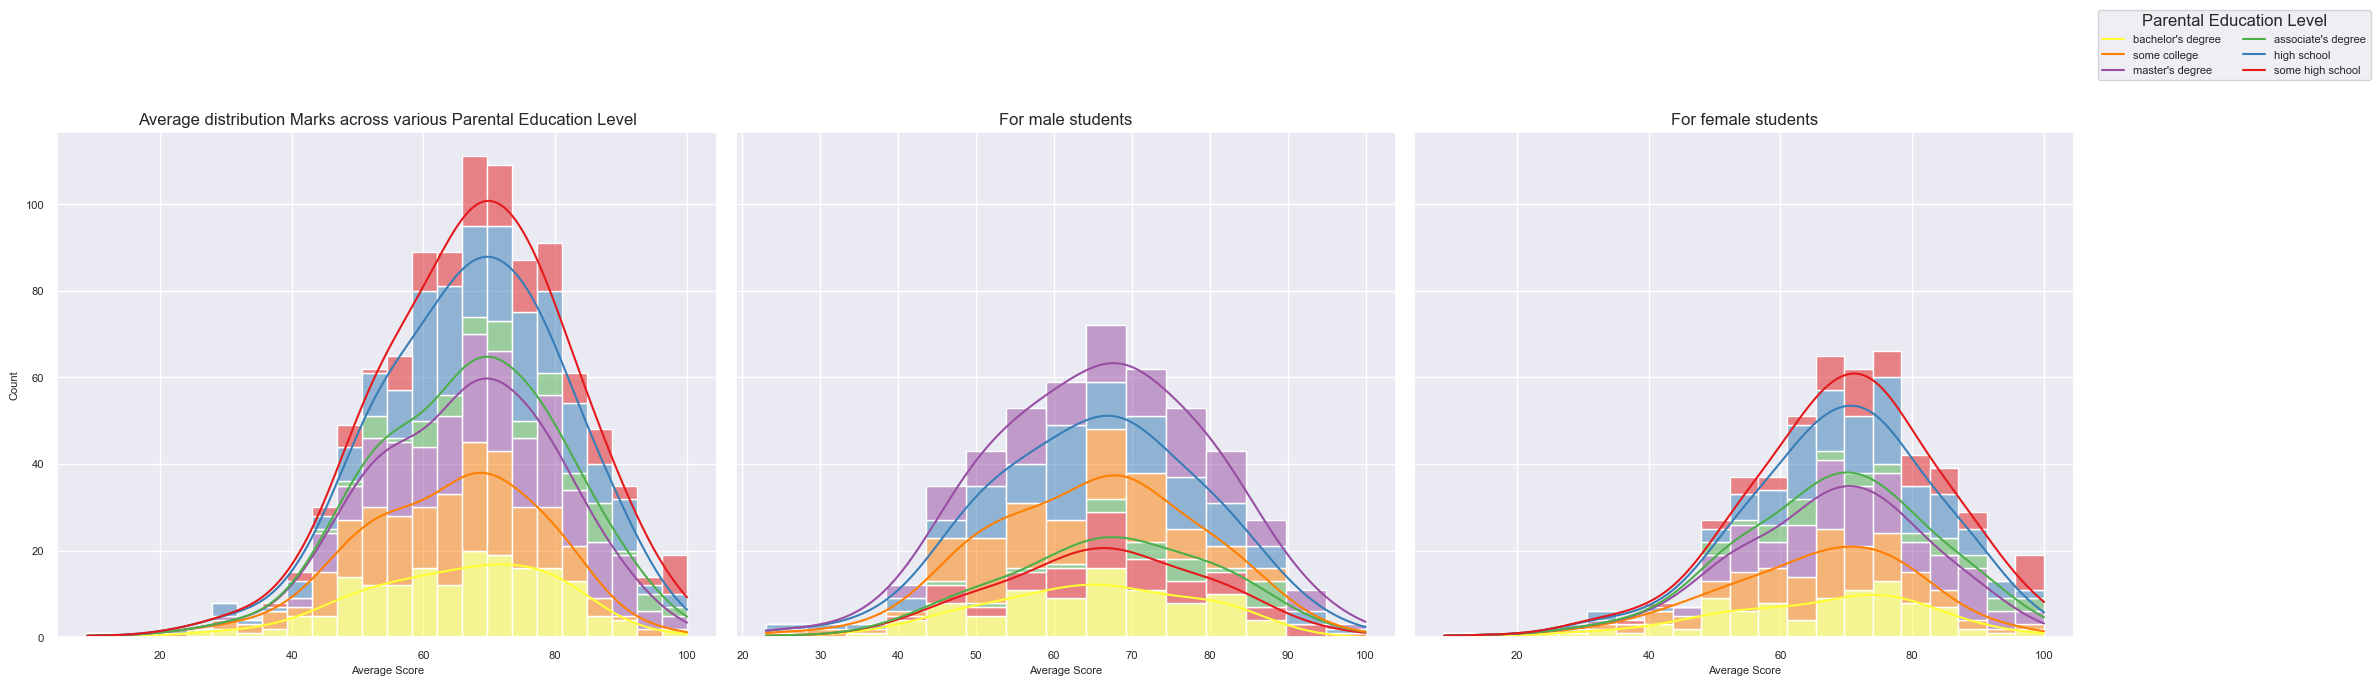

Plot displayed.


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique values in the 'parental level of education' column
education_level = df['parental level of education'].unique()
print(f"Unique Education Levels: {education_level}")

# Generate a color palette for each education level
color = sns.color_palette('Set1', len(education_level))
print(f"Color Palette: {color}")

# Create a dictionary to map each education level to its color
hue_colors = {}
for i, level in enumerate(education_level): 
    hue_colors[level] = color[i]
    print(f"Mapping {level} to color {color[i]}")

# Create a figure with 3 subplots, sharing the y-axis
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(21, 6))
print("Subplots created with 3 axes.")

# Plot histogram for all students, with 'parental level of education' as hue
sns.histplot(data=df, x='average', kde=True, hue='parental level of education', ax=axs[0], palette=hue_colors, legend=False, multiple="stack")
axs[0].set_title('Average distribution Marks across various Parental Education Level')
axs[0].set_xlabel('Average Score')
print("Plot 1 (All students) created.")

# Plot histogram for male students, with 'parental level of education' as hue
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='parental level of education', ax=axs[1], palette=hue_colors, legend=False, multiple="stack")
axs[1].set_title('For male students')
axs[1].set_xlabel('Average Score')
print("Plot 2 (Male students) created.")

# Plot histogram for female students, with 'parental level of education' as hue
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='parental level of education', ax=axs[2], palette=hue_colors, legend=False, multiple="stack")
axs[2].set_title('For female students')
axs[2].set_xlabel('Average Score')
print("Plot 3 (Female students) created.")

# Add a legend to the figure
fig.legend(loc='upper left', bbox_to_anchor=(1, 1.15), ncol=2, labels=hue_colors.keys(), title='Parental Education Level')
print("Legend added.")

# Adjust the layout to prevent overlap
fig.tight_layout()
print("Layout adjusted.")

# Display the plot
plt.show()
print("Plot displayed.")
